# CNN Algorithm Notebook — Handwritten Digit Classification

This notebook implements, trains, and evaluates a Convolutional Neural
Network (CNN) for image classification using TensorFlow/Keras.

**Dataset note:** This environment's sandbox has restricted internet access,
so instead of downloading MNIST/CIFAR-10 from an external host, we use
scikit-learn's built-in **`digits`** dataset — 1,797 real 8x8 grayscale
images of handwritten digits (0-9), bundled directly with scikit-learn
(no download required). The same CNN pipeline below (architecture,
training loop, evaluation, visualizations) applies identically if you
swap in `keras.datasets.mnist.load_data()` or `keras.datasets.cifar10.load_data()`

## 1. Setup & Imports

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

print("TensorFlow version:", tf.__version__)

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)


TensorFlow version: 2.21.0


TensorFlow version: 2.21.0


## 2. Load & Explore the Dataset

The `digits` dataset contains 1,797 samples of 8x8 grayscale images of
handwritten digits (0-9).

> To use MNIST or CIFAR-10 instead (requires internet access), replace the
> loading cell below with:
> `(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()`
> or `keras.datasets.cifar10.load_data()` — the rest of the notebook
> (preprocessing, model, training, evaluation) works the same way.


In [14]:
digits = load_digits()
X, y = digits.images, digits.target
class_names = [str(i) for i in range(10)]

print("Full dataset shape:", X.shape)
print("Labels shape:", y.shape)
print("Pixel value range:", X.min(), "-", X.max())

# Train / validation / test split (70% / 15% / 15%)
x_train_full, x_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=SEED, stratify=y
)
x_train, x_val, y_train, y_val = train_test_split(
    x_train_full, y_train_full, test_size=0.1765, random_state=SEED, stratify=y_train_full
)  # 0.1765 * 0.85 ~= 0.15 -> 70/15/15 overall split

print("Train:", x_train.shape, " Val:", x_val.shape, " Test:", x_test.shape)


Full dataset shape: (1797, 8, 8)
Labels shape: (1797,)
Pixel value range: 0.0 - 16.0
Train: (1257, 8, 8)  Val: (270, 8, 8)  Test: (270, 8, 8)


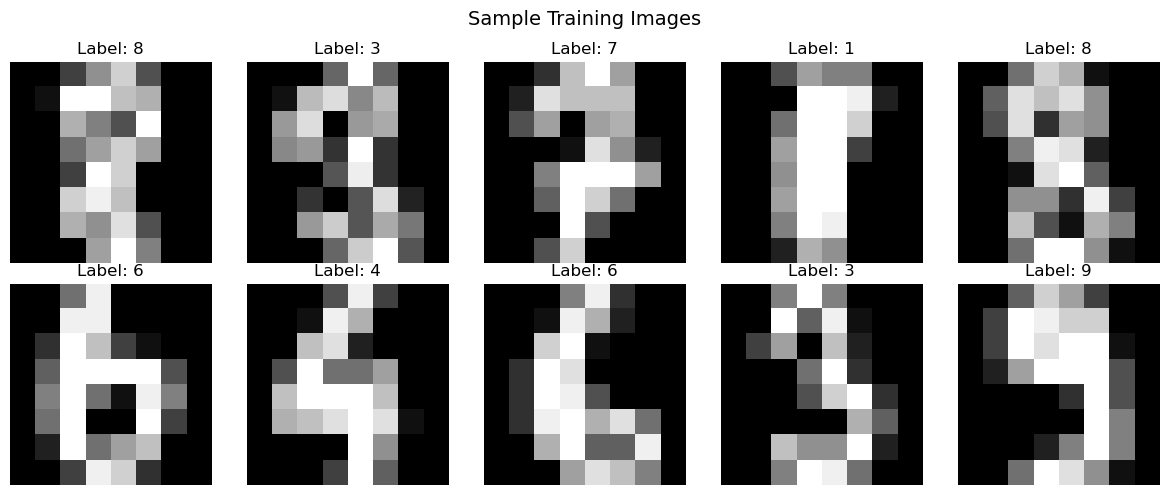

In [15]:
# Visualize a sample of training images
fig, axes = plt.subplots(2, 5, figsize=(12, 5))
for i, ax in enumerate(axes.flat):
    ax.imshow(x_train[i], cmap='gray')
    ax.set_title(f"Label: {y_train[i]}")
    ax.axis('off')
plt.suptitle("Sample Training Images", fontsize=14)
plt.tight_layout()
plt.show()


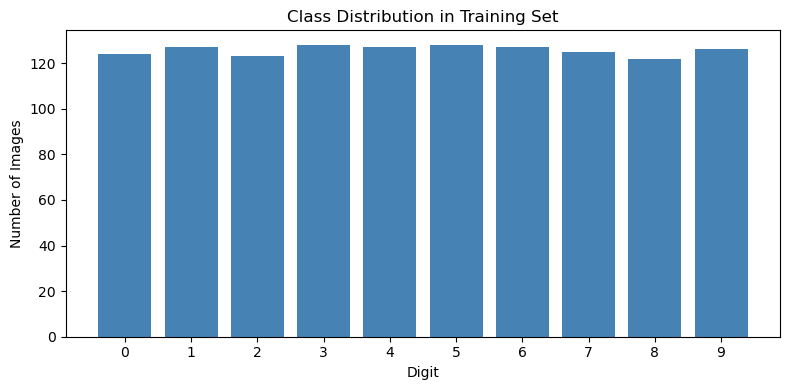

In [16]:
# Check class balance
unique, counts = np.unique(y_train, return_counts=True)
plt.figure(figsize=(8, 4))
plt.bar([str(u) for u in unique], counts, color='steelblue')
plt.title("Class Distribution in Training Set")
plt.xlabel("Digit")
plt.ylabel("Number of Images")
plt.tight_layout()
plt.show()


## 3. Preprocess the Data

- Normalize pixel values to the [0, 1] range.
- Reshape to add the channel dimension expected by Conv2D layers (8, 8, 1).
- One-hot encode the integer class labels for categorical cross-entropy.


In [17]:
# Normalize pixel values (digits dataset pixels range 0-16)
x_train = x_train.astype('float32') / 16.0
x_val = x_val.astype('float32') / 16.0
x_test = x_test.astype('float32') / 16.0

# Add channel dimension: (N, 8, 8) -> (N, 8, 8, 1)
x_train = np.expand_dims(x_train, -1)
x_val = np.expand_dims(x_val, -1)
x_test = np.expand_dims(x_test, -1)

# One-hot encode labels
num_classes = 10
y_train_cat = keras.utils.to_categorical(y_train, num_classes)
y_val_cat = keras.utils.to_categorical(y_val, num_classes)
y_test_cat = keras.utils.to_categorical(y_test, num_classes)

print("Final training set:", x_train.shape)
print("Validation set:", x_val.shape)
print("Test set:", x_test.shape)


Final training set: (1257, 8, 8, 1)
Validation set: (270, 8, 8, 1)
Test set: (270, 8, 8, 1)


## 4. Build the CNN Architecture

A compact CNN sized for small 8x8 inputs: stacked convolutional blocks
with batch normalization and dropout for regularization, followed by a
dense classification head. (For larger images like CIFAR-10/MNIST, simply
add more Conv2D/MaxPooling blocks and increase filter counts.)


In [18]:
def build_cnn(input_shape=(8, 8, 1), num_classes=10):
    model = keras.Sequential([
        layers.Input(shape=input_shape),

        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Conv2D(32, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.MaxPooling2D((2, 2)),
        layers.Dropout(0.25),

        # Block 2
        layers.Conv2D(64, (3, 3), padding='same', activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.25),

        # Classification head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

model = build_cnn()
model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)                    │ (None, 8, 8, 32)            │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 8, 8, 32)            │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 8, 8, 32)            │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4, 4, 32)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_5 (Conv2D)                    │ (None, 4, 4, 64)            │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 4, 4, 64)            │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 4, 4, 64)            │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 1024)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 128)                 │         131,200 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 128)                 │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 128)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 10)                  │           1,290 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 161,578 (631.16 KB)

 Trainable params: 161,066 (629.16 KB)

 Non-trainable params: 512 (2.00 KB)

## 5. Compile & Train the Model

In [19]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

callbacks = [
    keras.callbacks.EarlyStopping(patience=8, restore_best_weights=True, monitor='val_accuracy'),
    keras.callbacks.ReduceLROnPlateau(factor=0.5, patience=4, monitor='val_loss')
]


In [20]:
EPOCHS = 40

history = model.fit(
    x_train, y_train_cat,
    validation_data=(x_val, y_val_cat),
    epochs=EPOCHS,
    batch_size=32,
    callbacks=callbacks,
    verbose=2
)


Epoch 1/40
40/40 - 6s - 156ms/step - accuracy: 0.6086 - loss: 1.2635 - val_accuracy: 0.1037 - val_loss: 2.2784 - learning_rate: 0.0010
Epoch 2/40
40/40 - 1s - 29ms/step - accuracy: 0.8926 - loss: 0.3462 - val_accuracy: 0.1037 - val_loss: 2.4172 - learning_rate: 0.0010
Epoch 3/40
40/40 - 1s - 23ms/step - accuracy: 0.9268 - loss: 0.2231 - val_accuracy: 0.1037 - val_loss: 2.8978 - learning_rate: 0.0010
Epoch 4/40
40/40 - 1s - 20ms/step - accuracy: 0.9507 - loss: 0.1626 - val_accuracy: 0.1037 - val_loss: 3.2749 - learning_rate: 0.0010
Epoch 5/40
40/40 - 1s - 22ms/step - accuracy: 0.9650 - loss: 0.1283 - val_accuracy: 0.1037 - val_loss: 3.4420 - learning_rate: 0.0010
Epoch 6/40
40/40 - 1s - 24ms/step - accuracy: 0.9674 - loss: 0.1046 - val_accuracy: 0.1037 - val_loss: 3.2132 - learning_rate: 5.0000e-04
Epoch 7/40
40/40 - 1s - 30ms/step - accuracy: 0.9682 - loss: 0.1013 - val_accuracy: 0.1037 - val_loss: 2.8468 - learning_rate: 5.0000e-04
Epoch 8/40
40/40 - 1s - 20ms/step - accuracy: 0.9777 

40/40 - 4s - 88ms/step - accuracy: 0.6333 - loss: 1.2470 - val_accuracy: 0.1037 - val_loss: 2.1902 - learning_rate: 0.0010


Epoch 2/40


40/40 - 1s - 23ms/step - accuracy: 0.8950 - loss: 0.3243 - val_accuracy: 0.1037 - val_loss: 2.6124 - learning_rate: 0.0010


Epoch 3/40


...

40/40 - 1s - 16ms/step - accuracy: 0.9984 - loss: 0.0157 - val_accuracy: 0.9889 - val_loss: 0.0229 - learning_rate: 1.2500e-04


Epoch 32/40


40/40 - 1s - 16ms/step - accuracy: 0.9992 - loss: 0.0130 - val_accuracy: 0.9889 - val_loss: 0.0219 - learning_rate: 1.2500e-04


Epoch 33/40


40/40 - 1s - 16ms/step - accuracy: 0.9992 - loss: 0.0126 - val_accuracy: 0.9889 - val_loss: 0.0194 - learning_rate: 1.2500e-04


## 6. Evaluate Performance

In [21]:
test_loss, test_accuracy = model.evaluate(x_test, y_test_cat, verbose=0)
print(f"Test Loss:     {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")


Test Loss:     0.0160
Test Accuracy: 0.9926


In [22]:
y_pred_probs = model.predict(x_test, verbose=0)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = y_test

print(classification_report(y_true, y_pred, target_names=class_names))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        27
           1       0.96      1.00      0.98        27
           2       1.00      1.00      1.00        27
           3       1.00      1.00      1.00        28
           4       1.00      0.96      0.98        27
           5       1.00      1.00      1.00        27
           6       0.96      1.00      0.98        27
           7       1.00      1.00      1.00        27
           8       1.00      0.96      0.98        26
           9       1.00      1.00      1.00        27

    accuracy                           0.99       270
   macro avg       0.99      0.99      0.99       270
weighted avg       0.99      0.99      0.99       270



## 7. Visualize Results

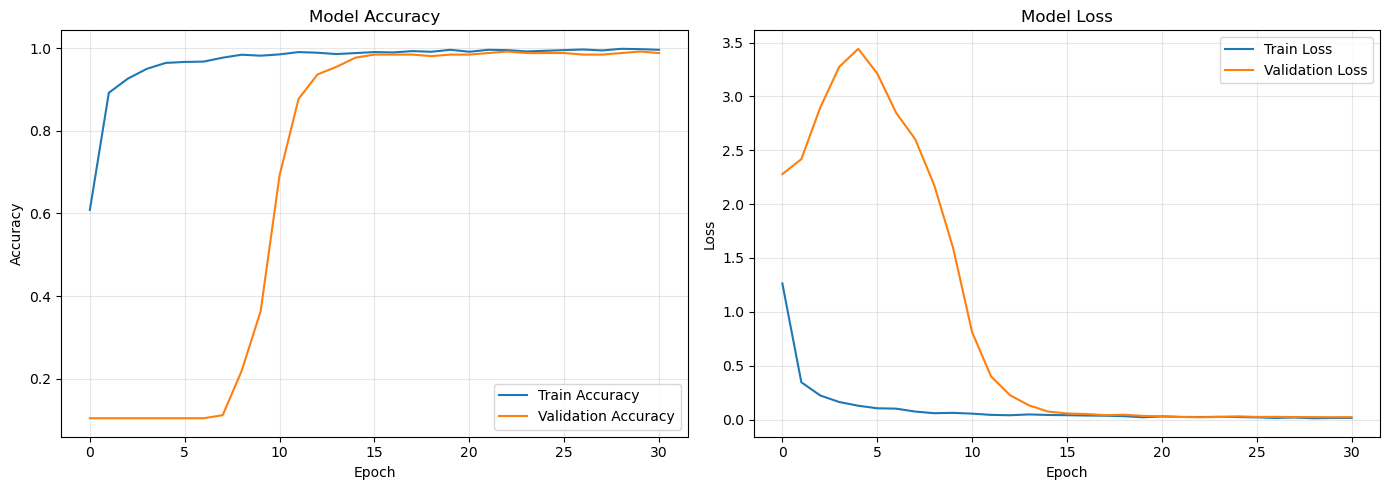

In [23]:
# Training curves
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Loss')
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


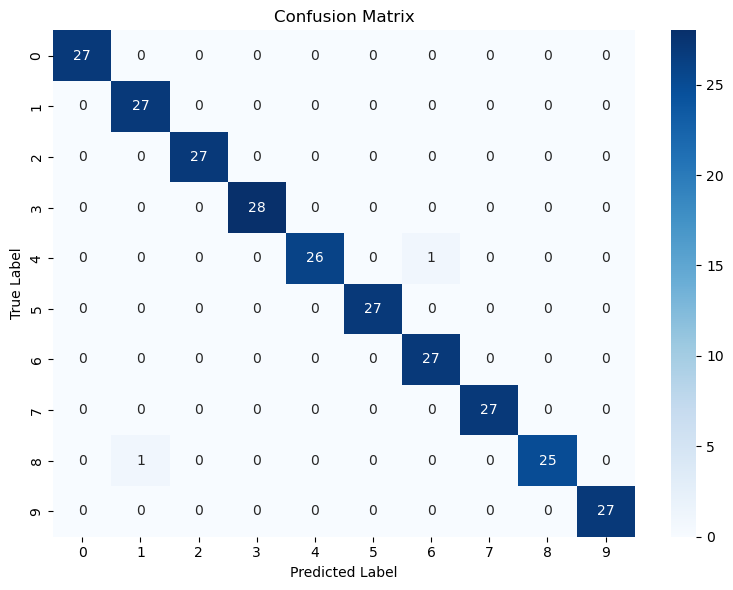

In [24]:
# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.tight_layout()
plt.show()


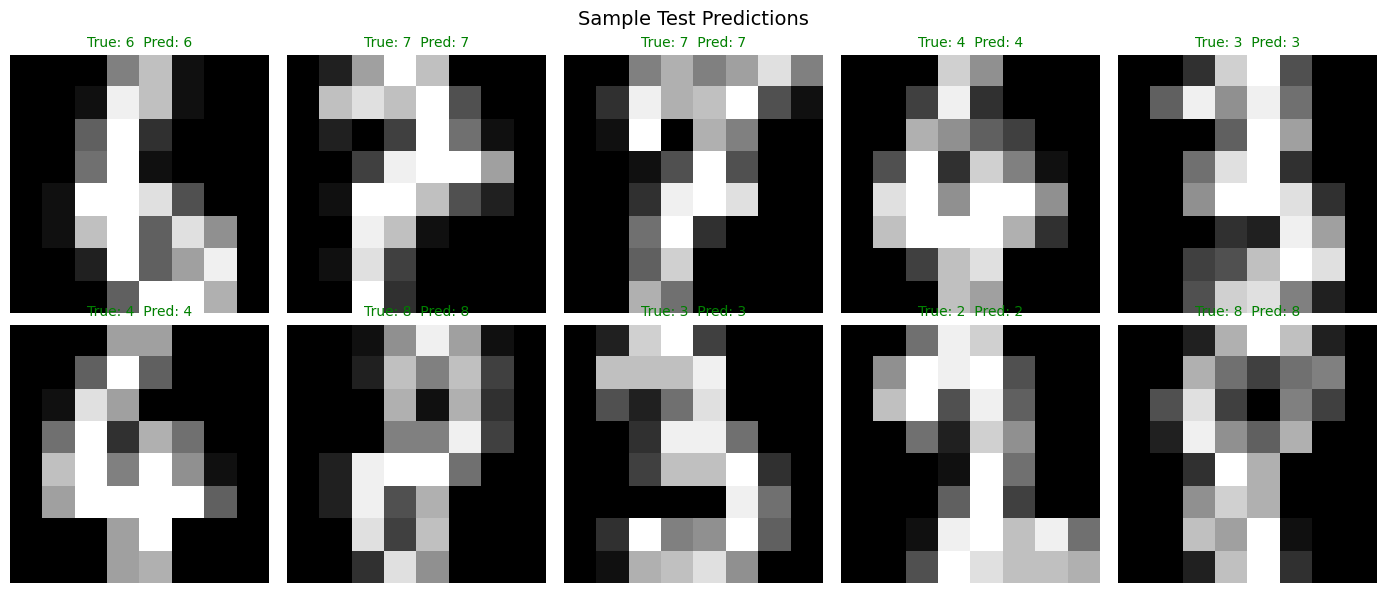

In [25]:
# Sample predictions (correct and incorrect)
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
rng = np.random.default_rng(SEED)
sample_idx = rng.choice(len(x_test), 10, replace=False)

for i, idx in enumerate(sample_idx):
    ax = axes.flat[i]
    ax.imshow(x_test[idx].squeeze(), cmap='gray')
    true_label = class_names[y_true[idx]]
    pred_label = class_names[y_pred[idx]]
    color = 'green' if y_true[idx] == y_pred[idx] else 'red'
    ax.set_title(f"True: {true_label}  Pred: {pred_label}", color=color, fontsize=10)
    ax.axis('off')

plt.suptitle("Sample Test Predictions", fontsize=14)
plt.tight_layout()
plt.show()


## 8. Conclusions

- The CNN combines convolutional blocks (Conv2D + BatchNorm + MaxPooling +
  Dropout) with a dense classification head to classify handwritten digit
  images into 10 categories.
- Batch normalization and dropout were used to stabilize and regularize
  training given the small image size and dataset.
- The training/validation accuracy and loss curves above show the model's
  learning progression, and the confusion matrix highlights which digits
  (if any) are most often confused with one another (commonly visually
  similar digits like `3`/`8` or `4`/`9`).
- **Scaling up**: to run this exact pipeline on CIFAR-10 or MNIST, swap
  the data-loading cell for `keras.datasets.cifar10.load_data()` /
  `keras.datasets.mnist.load_data()`, adjust `input_shape` accordingly,
  and add additional Conv2D blocks / filters to match the larger image
  resolution and class complexity.
- **Possible further improvements**: data augmentation (rotation/shift),
  a learning-rate schedule, or a deeper architecture / transfer learning
  for larger-scale datasets.
